In [1]:
import sqlite3, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import emoji
import nltk
from langdetect import detect, LangDetectException
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from pathlib import Path
from dotenv import load_dotenv
from gensim.models import FastText
from nltk.tokenize import word_tokenize
import hdbscan
import nltk
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 300)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [2]:
ROOT = Path.cwd().parent

load_dotenv(ROOT / '.env')
DB_PATH = str(ROOT / 'db' / 'gaming_warehouse.db')
IMAGENES_PATH = str(ROOT / 'Imagenes') + '/'

In [3]:
def Query(query, params=None):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    return df


# EDA

## estado de mis reseñas

In [4]:
df_estado = """
SELECT
    COUNT(*) AS total_resenas,
    COUNT(DISTINCT juego_id) AS juegos_distintos,
    ROUND(100.0 * COUNT(resena_texto) / COUNT(*), 1) AS pct_con_texto,
    ROUND(100.0 * COUNT(recomendado) / COUNT(*), 1) AS pct_con_recomendado,
    ROUND(100.0 * COUNT(votos_utiles) / COUNT(*), 1) AS pct_con_votos_utiles,
    ROUND(100.0 * COUNT(minutos_al_resenar) / COUNT(*), 1) AS pct_con_minutos,
    ROUND(100.0 * COUNT(fecha_creacion_unix) / COUNT(*), 1) AS pct_con_fecha,
    ROUND(100.0 * COUNT(recibido_gratis) / COUNT(*), 1) AS pct_con_gratis_flag
FROM Hist_Steam_Reviews
"""
display(Query(df_estado))
#bastante llena esta version

,total_resenas,juegos_distintos,pct_con_texto,pct_con_recomendado,pct_con_votos_utiles,pct_con_minutos,pct_con_fecha,pct_con_gratis_flag
0,600194,5825,100.00,100.00,100.00,100.00,100.00,100.00


## obtener los datos

In [5]:
#Puras reseñas limpias
carga = """
SELECT
    x.resena_id,
    x.juego_id,
    y.titulo,
    x.resena_texto,
    x.recomendado,
    x.votos_utiles,
    x.votos_graciosos,
    x.puntuacion_ponderada,
    x.minutos_al_resenar,
    x.minutos_totales,
    x.fecha_creacion_unix,
    x.autor_num_resenas,
    x.autor_num_juegos,
    x.recibido_gratis,
    x.escrito_acceso_anticipado
FROM Hist_Steam_Reviews x
JOIN CAT_Juego y ON x.juego_id = y.juego_id
WHERE x.resena_texto IS NOT NULL
  AND TRIM(x.resena_texto) != ''
"""

df_carga = Query(carga)


In [6]:
#df_carga

In [7]:
# obtension de datos de fechas
df_carga['fecha'] = pd.to_datetime(df_carga['fecha_creacion_unix'], unit='s', errors='coerce')
df_carga['anio'] = df_carga['fecha'].dt.year
df_carga['mes'] = df_carga['fecha'].dt.to_period('M')

# Horas al reseñar
df_carga['horas_al_resenar'] = df_carga['minutos_al_resenar'] / 60


In [8]:
print(f'{len(df_carga):,}')
print(f'Juegos unicos: {df_carga["juego_id"].nunique():,}')

599,411
Juegos unicos: 5,825


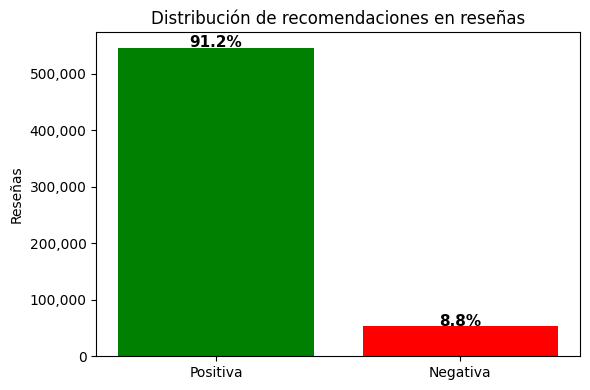

recomendado
Positiva    546371
Negativa     53040


In [9]:
conteo = df_carga['recomendado'].value_counts().rename({1: 'Positiva', 0: 'Negativa'})
pct    = (conteo / conteo.sum() * 100).round(1)

titulo='Distribución de recomendaciones en reseñas'

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conteo.index, conteo.values, color=['green', 'red'])
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{p}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

print(conteo.to_string())

#parce que es mas gente la que recomienda juegos que la que no lo hace
#bsatante desvbalance

## palabras y letras por reseñas


In [10]:
df_carga['n_palabras'] = df_carga['resena_texto'].str.split().str.len()
df_carga['n_chars']    = df_carga['resena_texto'].str.len()

print('Palabras por reseña')
display(df_carga['n_palabras'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print('Caracteres por reseña')
display(df_carga['n_chars'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

Palabras por reseña


count   599,411.00
mean         41.82
std          95.40
min           0.00
25%           4.00
50%          13.00
75%          38.00
90%          98.00
95%         177.00
99%         465.00
max       2,034.00
Name: n_palabras, dtype: float64

Caracteres por reseña


count   599,411.00
mean        245.96
std         568.97
min           1.00
25%          20.00
50%          70.00
75%         224.00
90%         575.00
95%       1,030.00
99%       2,858.00
max       8,000.00
Name: n_chars, dtype: float64

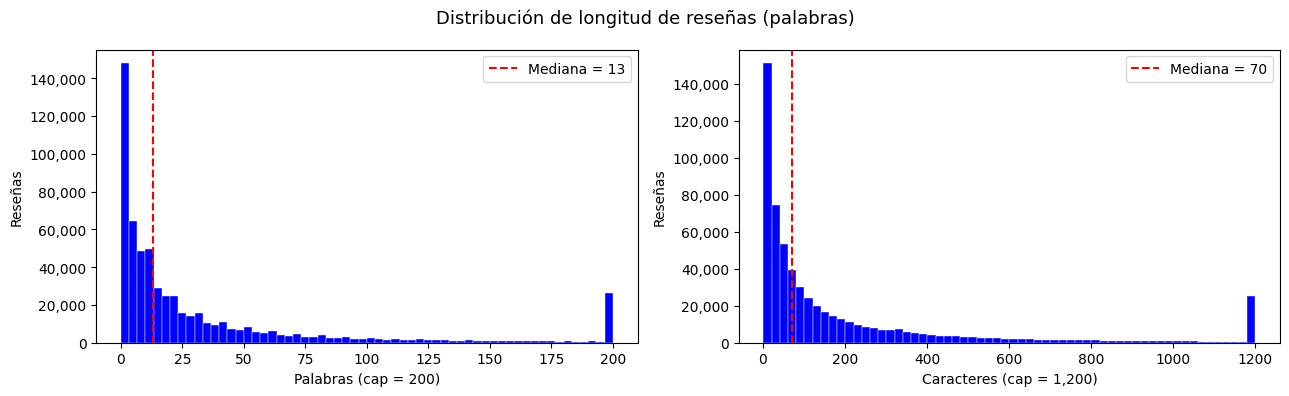

In [11]:
titulo = 'Distribución de longitud de reseñas (palabras)'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, cap in [
    (axes[0], 'n_palabras', 'Palabras', 200),
    (axes[1], 'n_chars',    'Caracteres', 1200),
]:
    data = df_carga[col].clip(upper=cap)
    ax.hist(data, bins=60, color='blue', edgecolor='white', linewidth=0.3)
    mediana = df_carga[col].median()
    ax.axvline(mediana, color='red', linestyle='--', label=f'Mediana = {mediana:.0f}')
    ax.set_xlabel(f'{label} (cap = {cap:,})')
    ax.set_ylabel('Reseñas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()

fig.suptitle(titulo, fontsize=13)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Votos utiles

In [12]:
display(df_carga['votos_utiles'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

count   599,411.00
mean          1.16
std           6.62
min           0.00
25%           0.00
50%           0.00
75%           1.00
90%           2.00
95%           5.00
99%          17.00
max       1,475.00
Name: votos_utiles, dtype: float64

In [13]:
cero = (df_carga['votos_utiles'] == 0).sum()
print(f'Con 0 votos útiles: {cero:,} ({cero/len(df_carga)*100:f}%)')

Con 0 votos útiles: 423,452 (70.644683%)


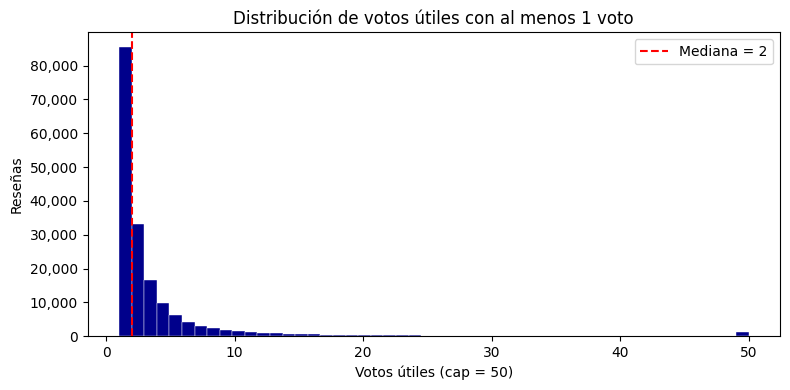

Reseñas con ≥1 voto: 175,959 (29.4%)
count   175,959.00
mean          3.96
std          11.75
min           1.00
50%           2.00
75%           3.00
90%           7.00
95%          13.00
99%          41.00
max       1,475.00


In [14]:
titulo = 'Distribución de votos útiles con al menos 1 voto'

data = df_carga[df_carga['votos_utiles'] > 0]['votos_utiles']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data.clip(upper=50), bins=50, color='darkblue', edgecolor='white', linewidth=0.3)
mediana = data.median()
ax.axvline(mediana, color='red', linestyle='--', label=f'Mediana = {mediana:.0f}')
ax.set_xlabel('Votos útiles (cap = 50)')
ax.set_ylabel('Reseñas')
ax.set_title(titulo)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Reseñas con ≥1 voto: {len(data):,} ({len(data)/len(df_carga)*100:.1f}%)')
print(data.describe(percentiles=[.5,.75,.90,.95,.99]).to_string())

## tiempo al reseñar

In [15]:
display(df_carga['horas_al_resenar'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

count   599,411.00
mean         65.48
std         311.62
min           0.02
25%           4.83
50%          13.33
75%          38.77
90%         107.98
95%         216.53
99%         999.95
max      22,181.62
Name: horas_al_resenar, dtype: float64

In [16]:
horas = df_carga['horas_al_resenar']
print(f'Reseñas con >10,000 horas: {(horas > 10000).sum():,}')
print(f'Reseñas con >1,000 horas: {(horas > 1000).sum():,}')
print(f'Reseñas con <1 hora:{(horas < 1).sum():,}')# gente que jugo un rato y solo opino

Reseñas con >10,000 horas: 79
Reseñas con >1,000 horas: 5,990
Reseñas con <1 hora:35,916


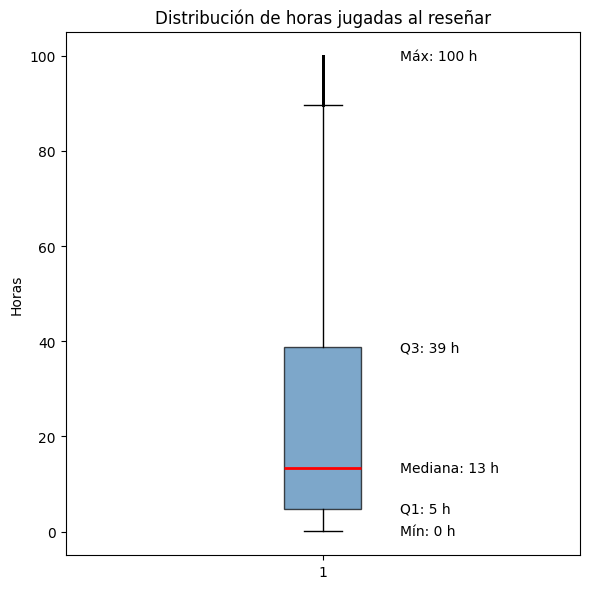

In [17]:
titulo = 'Distribución de horas jugadas al reseñar'
horas = df_carga['horas_al_resenar']
CAP = 100

data = horas.clip(upper=CAP)

fig, ax = plt.subplots(figsize=(6, 6))
bp = ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))
ax.set_title(titulo)
ax.set_ylabel('Horas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anotar valores clave
stats = {
    'Mín':    horas.min(),
    'Q1':     horas.quantile(0.25),
    'Mediana':horas.median(),
    'Q3':     horas.quantile(0.75),
    'Máx':    horas.clip(upper=CAP).max(),
}
for nombre, valor in stats.items():
    ax.annotate(f'{nombre}: {valor:.0f} h',
                xy=(1, min(valor, CAP)),
                xytext=(1.15, min(valor, CAP)),
                fontsize=10,
                va='center')

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

##porcion de juegos comprados

In [18]:
display(df_carga['recibido_gratis'].value_counts())
display(df_carga['recibido_gratis'].value_counts(normalize=True).mul(100).round(1))

recibido_gratis
0    570685
1     28726
Name: count, dtype: int64

recibido_gratis
0   95.20
1    4.80
Name: proportion, dtype: float64

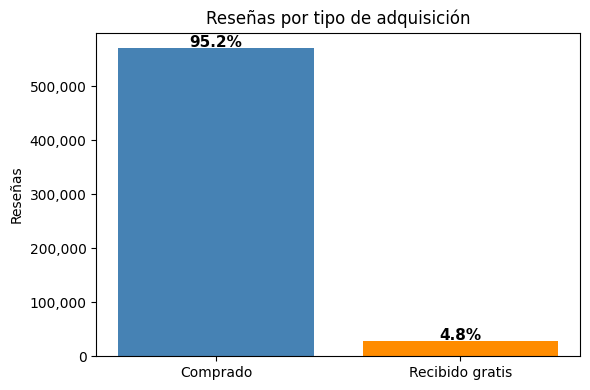

In [19]:
titulo = 'Reseñas por tipo de adquisición'

conteo = df_carga['recibido_gratis'].value_counts().rename({0: 'Comprado', 1: 'Recibido gratis'})
pct    = (conteo / conteo.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conteo.index, conteo.values, color=['steelblue', 'darkorange'])
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{p}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## ver las fechas

In [20]:
df_carga['fecha'] = pd.to_datetime(df_carga['fecha_creacion_unix'], unit='s', errors='coerce')
print(f'Desde: {df_carga["fecha"].min()}')
print(f'Hasta: {df_carga["fecha"].max()}')
print(f'Nulos: {df_carga["fecha"].isna().sum()}')

Desde: 2010-10-30 05:58:25
Hasta: 2026-04-10 09:40:47
Nulos: 0


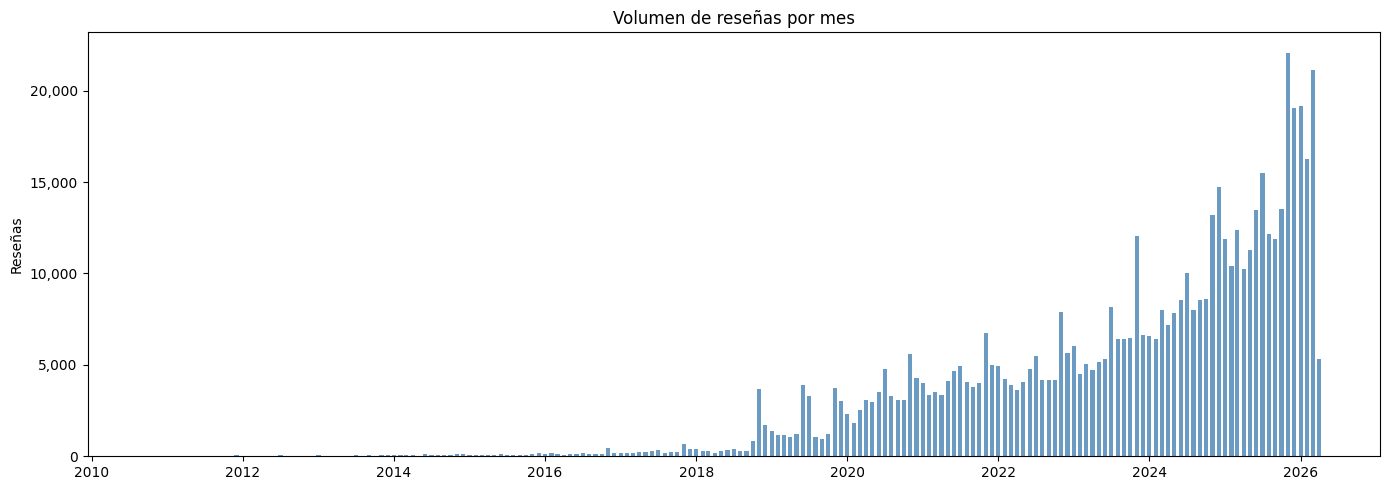

In [21]:
titulo = 'Volumen de reseñas por mes'

df_carga['mes'] = df_carga['fecha'].dt.to_period('M')
vol_mes = df_carga.groupby('mes').size().reset_index(name='total')
vol_mes['mes_dt'] = vol_mes['mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(vol_mes['mes_dt'], vol_mes['total'], width=20, color='steelblue', alpha=0.8)
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# es creciente las fechas hacia aca porque tome las primeras 1000 de cad juego y puede que muchso tengasn recientes y se acumularon a la dercha y 
# algunos cuantos ala querer alcanzar las 1000 se fueron hasta mas atras

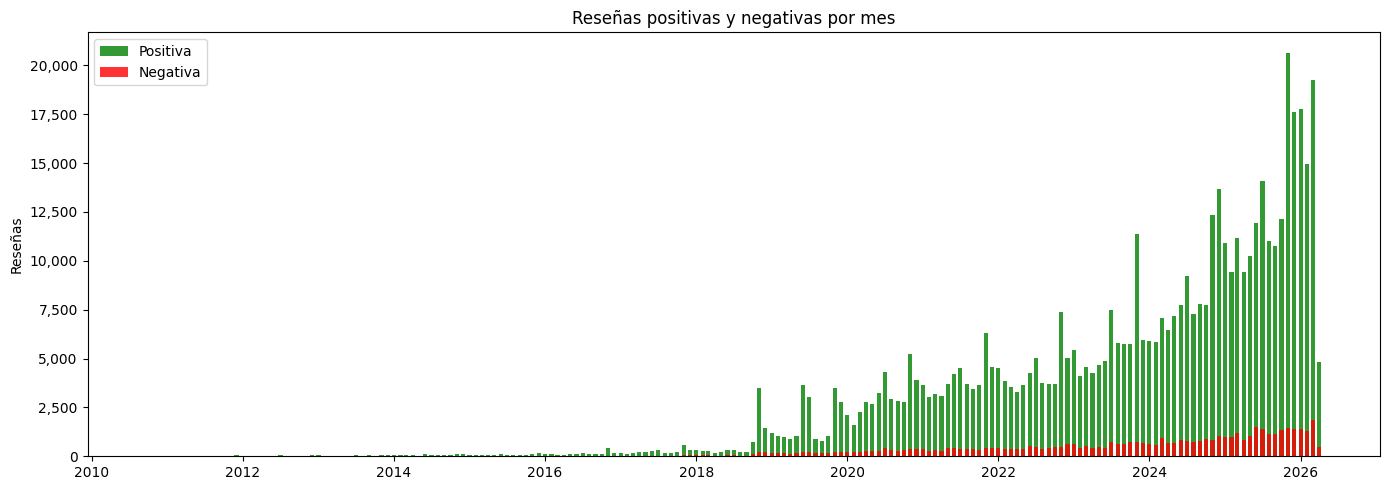

In [22]:
titulo = 'Reseñas positivas y negativas por mes'

vol_mes = (df_carga.groupby(['mes', 'recomendado'])
                   .size()
                   .reset_index(name='total'))
vol_mes['mes_dt'] = vol_mes['mes'].dt.to_timestamp()

pos = vol_mes[vol_mes['recomendado'] == 1]
neg = vol_mes[vol_mes['recomendado'] == 0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pos['mes_dt'], pos['total'], width=20, color='green',  alpha=0.8, label='Positiva')
ax.bar(neg['mes_dt'], neg['total'], width=20, color='red',    alpha=0.8, label='Negativa')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## horas jugdas y opiniones

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_34404\3380437481.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


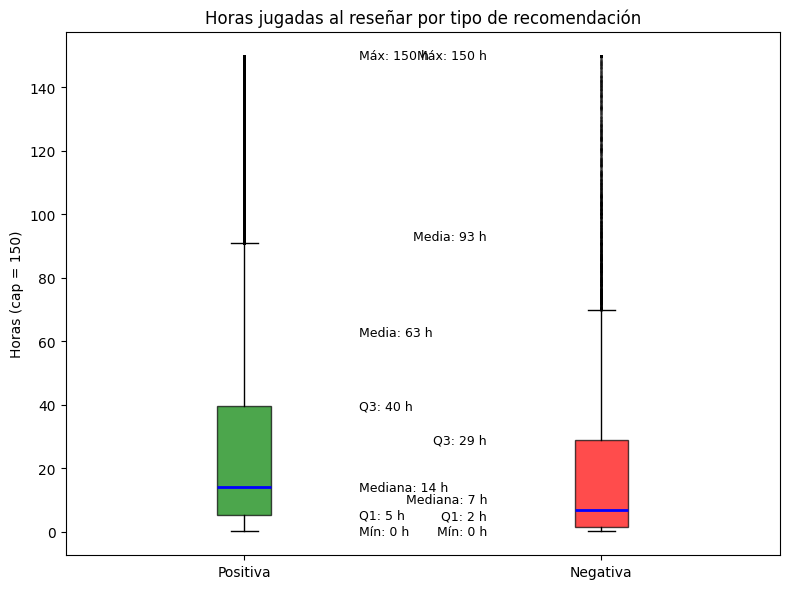

In [23]:
titulo = 'Horas jugadas al reseñar por tipo de recomendación'

horas = df_carga['horas_al_resenar']
CAP = 150

fig, ax = plt.subplots(figsize=(8, 6))
grupos = {
    'Positiva': horas[df_carga['recomendado'] == 1],
    'Negativa':  horas[df_carga['recomendado'] == 0],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

for i, (label, data) in enumerate(grupos.items(), start=1):
    stats = [
        ('Mín',max(data.min(), 0)),
        ('Q1', data.quantile(0.25)),
        ('Mediana', data.median()),
        ('Q3', data.quantile(0.75)),
        ('Media', data.mean()),
        ('Máx', min(data.max(), CAP)),
    ]
    offset_x = 0.32 if i == 1 else -0.32
    ha = 'left' if i == 1 else 'right'

    prev_y = -999
    for nombre, valor in stats:
        y = min(valor, CAP)
        # Si está muy cerca del anterior, empujar hacia arriba
        y_text = y if abs(y - prev_y) > 4 else prev_y + 5
        prev_y = y_text
        ax.annotate(f'{nombre}: {valor:.0f} h',
                    xy=(i, y),
                    xytext=(i + offset_x, y_text),
                    fontsize=9, va='center', ha=ha)

ax.set_title(titulo)
ax.set_ylabel(f'Horas (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## reseñas por juegos

In [24]:
por_juego = df_carga.groupby(['juego_id', 'titulo']).size().reset_index(name='total').sort_values('total', ascending=False)

print(f'Juegos con ≥1 reseña: {len(por_juego):,}')
print(f'Juegos con ≥10 reseñas: {(por_juego["total"] >= 10).sum():,}')
print(f'Juegos con ≥100 reseñas: {(por_juego["total"] >= 100).sum():,}')
print(f'Juegos con ≥1000 reseñas:{(por_juego["total"] >= 1000).sum():,}')
print()
print('Top 15 juegos por volumen:')
display(por_juego.head(15))

Juegos con ≥1 reseña: 5,825
Juegos con ≥10 reseñas: 3,918
Juegos con ≥100 reseñas: 1,243
Juegos con ≥1000 reseñas:51

Top 15 juegos por volumen:


,juego_id,titulo,total
172,226,PUBG: Battlegrounds,1002
428,581,Rust,1002
195,257,Rainbow Six Siege,1002
520,704,Black Myth: Wukong,1001
373,498,Helldivers 2,1001
28,36,Life is Strange,1000
663,920,The Last of Us Part II Remastered,1000
108,139,Cuphead,1000
927,1314,Duck Game,1000
21,27,Elden Ring,1000


In [25]:
display(por_juego.tail(15))
print()
print(por_juego['total'].describe(percentiles=[.25,.5,.75,.90,.95]).to_string())

,juego_id,titulo,total
5420,9398,Spirittea,1
2949,4803,Cossacks II: Napoleonic Wars,1
2946,4792,Leisure Suit Larry: Reloaded,1
2944,4783,De Blob 2,1
5453,9445,BloodRayne Betrayal: Fresh Bites,1
5452,9444,Minds Beneath Us,1
2880,4682,Tchia,1
5435,9420,100 Hidden Dogs,1
2906,4725,Touhou Kaeizuka: Phantasmagoria of Flower View,1
2922,4749,The Solus Project,1



count   5,825.00
mean      102.90
std       212.72
min         1.00
25%         6.00
50%        21.00
75%        78.00
90%       280.60
95%       618.00
max     1,002.00


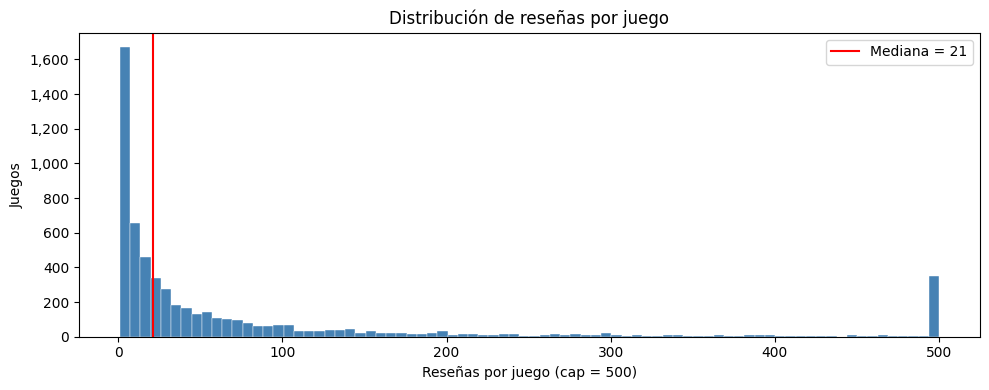

In [26]:
titulo = 'Distribución de reseñas por juego'

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(por_juego['total'].clip(upper=500), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
mediana = por_juego['total'].median()
ax.axvline(mediana, color='red', label=f'Mediana = {mediana:.0f}')
ax.set_title(titulo)
ax.set_xlabel('Reseñas por juego (cap = 500)')
ax.set_ylabel('Juegos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Horas jugadas vs votos útiles

In [27]:
display(df_carga[['horas_al_resenar', 'votos_utiles']].corr())
# al menos linelemente no veo correlacion entre las reviws utiles y las horas al reseñar

,horas_al_resenar,votos_utiles
horas_al_resenar,1.00,0.01
votos_utiles,0.01,1.00


## Longitud del texto vs votos útiles

In [28]:
display(df_carga[['n_palabras', 'votos_utiles']].corr())
# ya ahy por lo menos algo de realcion el la logitud de texto y utilidad, pude que la escriobir mas puede que se diga algo importante
# pero es muy bajo

,n_palabras,votos_utiles
n_palabras,1.00,0.13
votos_utiles,0.13,1.00


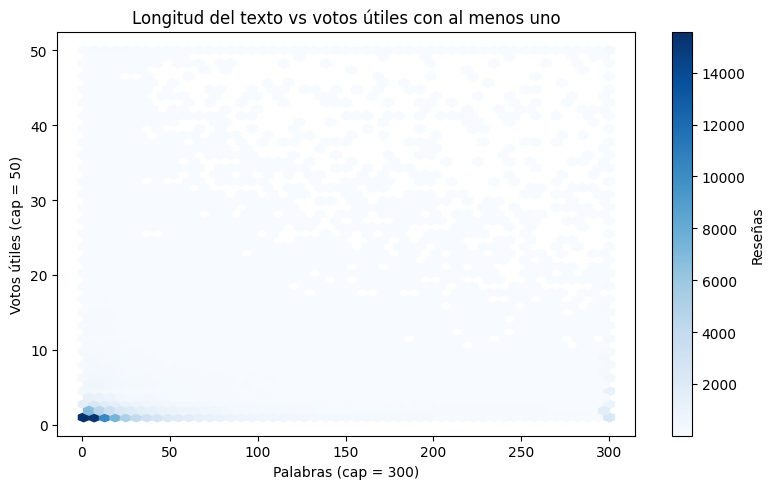

In [29]:
titulo = 'Longitud del texto vs votos útiles con al menos uno'

df_filtrado = df_carga[(df_carga['votos_utiles'] >= 1) & (df_carga['n_palabras'] >= 1)]

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(
    df_filtrado['n_palabras'].clip(upper=300),
    df_filtrado['votos_utiles'].clip(upper=50),
    gridsize=50, cmap='Blues', mincnt=1
)
plt.colorbar(hb, ax=ax, label='Reseñas')
ax.set_title(titulo)
ax.set_xlabel('Palabras (cap = 300)')
ax.set_ylabel('Votos útiles (cap = 50)')
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Longitud del texto vs recomendación

In [30]:
display(df_carga.groupby('recomendado')['n_palabras'].describe(percentiles=[.25,.5,.75,.90,.95]))
# parece que las resenas que no recomindan tienden a escribir mas, tienen mas que decir

,count,mean,std,min,25%,50%,75%,90%,95%,max
recomendado,,,,,,,,,,
0,"53,040.00",64.35,118.03,0.00,9.00,26.00,68.00,154.00,252.00,"1,523.00"
1,"546,371.00",39.64,92.61,0.00,3.00,12.00,35.00,92.00,168.00,"2,034.00"


C:\Users\ADRIA\AppData\Local\Temp\ipykernel_34404\3350676171.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


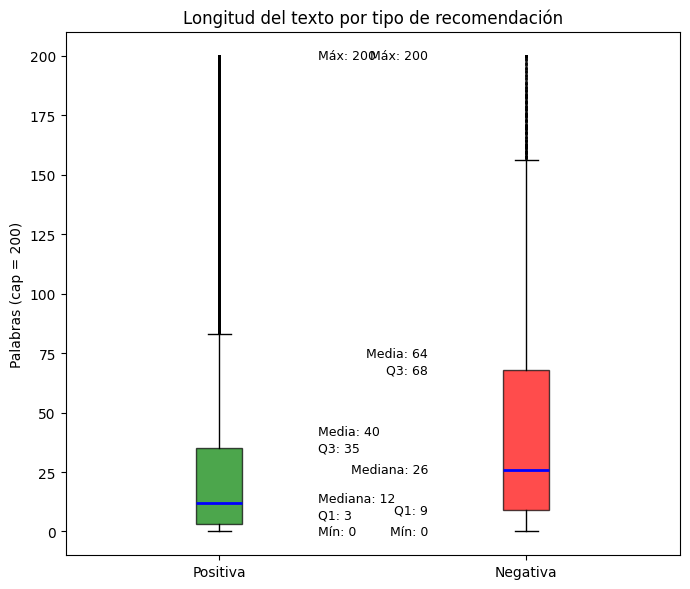

In [31]:
titulo = 'Longitud del texto por tipo de recomendación'

CAP = 200
fig, ax = plt.subplots(figsize=(7, 6))

grupos = {
    'Positiva': df_carga[df_carga['recomendado'] == 1]['n_palabras'],
    'Negativa':  df_carga[df_carga['recomendado'] == 0]['n_palabras'],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

for i, (label, data) in enumerate(grupos.items(), start=1):
    stats = [
        ('Mín', max(data.min(), 0)),
        ('Q1', data.quantile(0.25)),
        ('Mediana', data.median()),
        ('Q3', data.quantile(0.75)),
        ('Media', data.mean()),
        ('Máx', min(data.max(), CAP)),
    ]
    offset_x = 0.32 if i == 1 else -0.32
    ha = 'left' if i == 1 else 'right'
    prev_y = -999
    for nombre, valor in stats:
        y = min(valor, CAP)
        y_text = y if abs(y - prev_y) > 6 else prev_y + 7
        prev_y = y_text
        ax.annotate(f'{nombre}: {valor:.0f}',
                    xy=(i, y), xytext=(i + offset_x, y_text),
                    fontsize=9, va='center', ha=ha)

ax.set_title(titulo)
ax.set_ylabel(f'Palabras (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Recibido gratis vs recomendación

In [32]:
display(df_carga.groupby('recibido_gratis')['recomendado'].agg(['mean','count']).rename(columns={'mean':'pct_positiva','count':'total'}))

,pct_positiva,total
recibido_gratis,,
0,0.91,570685
1,0.86,28726


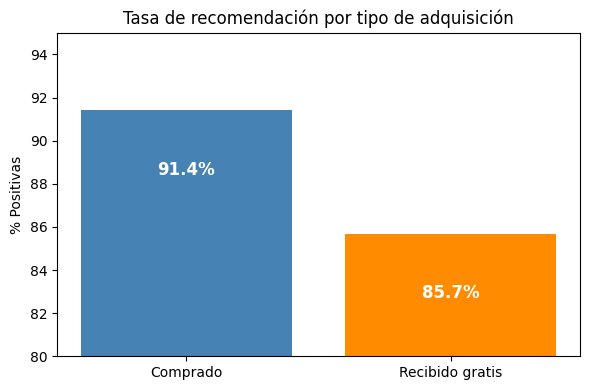

In [33]:
titulo = 'Tasa de recomendación por tipo de adquisición'

data = df_carga.groupby('recibido_gratis')['recomendado'].mean() * 100
data.index = ['Comprado', 'Recibido gratis']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(data.index, data.values, color=['steelblue', 'darkorange'])
for bar, v in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
            f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold', color='white')
ax.set_title(titulo)
ax.set_ylabel('% Positivas')
ax.set_ylim(80, 95)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# recibir un juego gratis no exime que tenga mas recomendacion, de ehco tien menos, esto pude ser poque realmente ningun juego es gratis y 
# esos puden tener metodos de compra que pueden provocar menos recomendaciones

##  Longitud del texto vs horas jugadas

In [34]:
display(df_carga[['n_palabras', 'horas_al_resenar']].corr())
# jugar más horas no hace que escribas más, al menos no hay relacion lineal

,n_palabras,horas_al_resenar
n_palabras,1.00,0.00
horas_al_resenar,0.00,1.00


## Votos útiles vs recomendación

In [35]:
display(df_carga.groupby('recomendado')['votos_utiles'].describe(percentiles=[.25,.5,.75,.90,.95]))
#las negativas reciben más del doble de votos útiles en media y del cuartil hacia arriba

,count,mean,std,min,25%,50%,75%,90%,95%,max
recomendado,,,,,,,,,,
0,"53,040.00",2.44,13.62,0.00,0.00,0.00,2.00,5.00,9.00,"1,475.00"
1,"546,371.00",1.04,5.46,0.00,0.00,0.00,1.00,2.00,4.00,806.00


C:\Users\ADRIA\AppData\Local\Temp\ipykernel_34404\2414872990.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


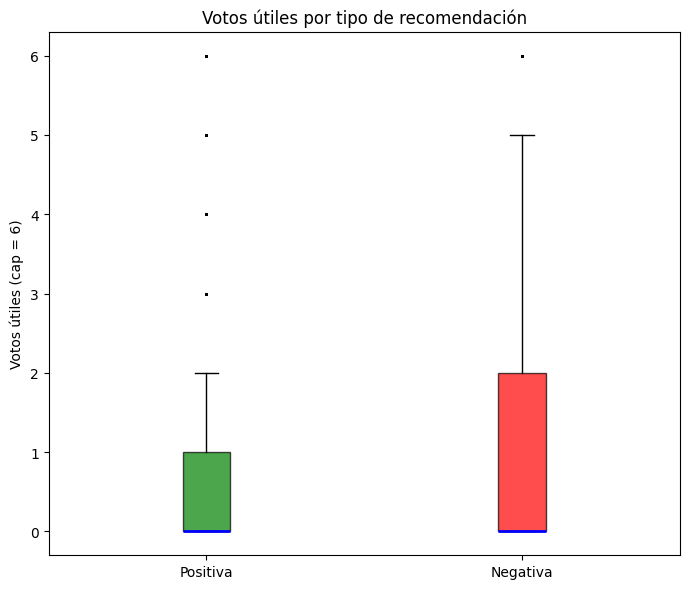

Positiva: mín=0  Q1=0  mediana=0  Q3=1  media=1.0  máx=806
Negativa: mín=0  Q1=0  mediana=0  Q3=2  media=2.4  máx=1475


In [36]:
titulo = 'Votos útiles por tipo de recomendación'

CAP = 6
fig, ax = plt.subplots(figsize=(7, 6))

grupos = {
    'Positiva': df_carga[df_carga['recomendado'] == 1]['votos_utiles'],
    'Negativa':  df_carga[df_carga['recomendado'] == 0]['votos_utiles'],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

ax.set_title(titulo)
ax.set_ylabel(f'Votos útiles (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticos por separado
for label, data in grupos.items():
    print(f'{label}: mín={data.min():.0f}  Q1={data.quantile(.25):.0f}  mediana={data.median():.0f}  Q3={data.quantile(.75):.0f}  media={data.mean():.1f}  máx={data.max():.0f}')

## Año de la reseña vs longitud

In [37]:
print('')
display(df_carga.groupby('anio')['n_palabras'].describe(percentiles=[.25,.5,.75]).round(1))

,count,mean,std,min,25%,50%,75%,max
anio,,,,,,,,
2010,48.00,40.10,34.90,2.00,15.50,27.00,58.20,160.00
2011,202.00,36.60,43.50,1.00,11.00,21.00,47.00,307.00
2012,281.00,45.10,66.90,1.00,10.00,23.00,54.00,562.00
2013,499.00,42.80,68.10,0.00,8.00,19.00,51.50,773.00
2014,887.00,92.00,152.20,1.00,13.50,39.00,104.50,"1,307.00"
2015,"1,122.00",108.00,184.40,0.00,15.00,43.00,111.00,"1,322.00"
2016,"1,905.00",99.00,176.00,1.00,13.00,37.00,102.00,"1,477.00"
2017,"3,284.00",89.70,146.10,1.00,14.00,39.00,103.20,"1,373.00"
2018,"8,995.00",67.80,126.60,0.00,9.00,26.00,69.00,"1,491.00"


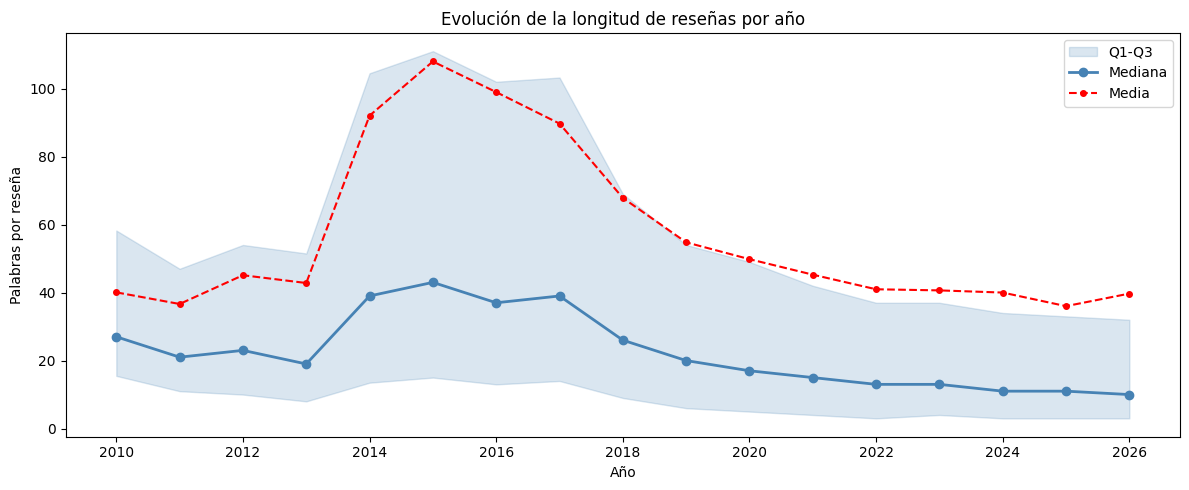

In [38]:
titulo = 'Evolución de la longitud de reseñas por año'

resumen_anio = df_carga.groupby('anio')['n_palabras'].agg(
    mediana='median', media='mean', q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(resumen_anio['anio'], resumen_anio['q1'], resumen_anio['q3'], alpha=0.2, color='steelblue', label='Q1-Q3')
ax.plot(resumen_anio['anio'], resumen_anio['mediana'], color='steelblue', linewidth=2, marker='o', label='Mediana')
ax.plot(resumen_anio['anio'], resumen_anio['media'],   color='red',      linewidth=1.5, linestyle='--', marker='o', markersize=4, label='Media')
ax.set_title(titulo)
ax.set_ylabel('Palabras por reseña')
ax.set_xlabel('Año')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Reseñas por juego vs % positivas

In [39]:
por_juego = df_carga.groupby(['juego_id', 'titulo']).agg(
    total = ('resena_id', 'count'),
    pct_pos= ('recomendado', 'mean')
).reset_index().sort_values('total', ascending=False)

display(por_juego[['total', 'pct_pos']].corr())
#Los juegos con más reseñas no necesariamente tienen mejor o peor rating.

,total,pct_pos
total,1.00,0.08
pct_pos,0.08,1.00


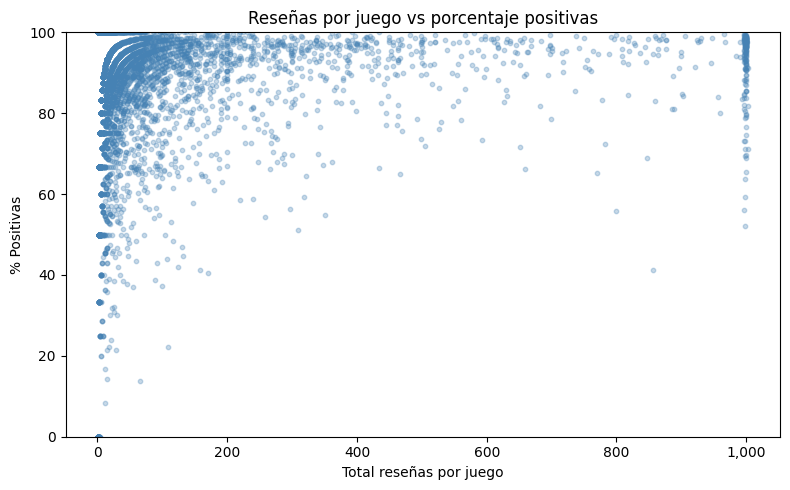

In [40]:
titulo = 'Reseñas por juego vs porcentaje positivas'

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(por_juego['total'], por_juego['pct_pos'] * 100,
           alpha=0.3, s=10, color='steelblue')
ax.set_title(titulo)
ax.set_xlabel('Total reseñas por juego')
ax.set_ylabel('% Positivas')
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()
#Los juegos con pocas reseñas tienen varianza enorme
# pueden estar en cualquier punto entre 0% y 100% porque con 1-5 reseñas cualquier cosa es posible
# Conforme aumentan las reseñas la varianza se comprime y converge hacia el 80-90% que es el promedio general.

# notas de EDA

- parce que es mas gente la que recomienda juegos que la que no lo hace
- bsatante desvbalance
- la mitad de las reseñas son muy cortas con 13 palabras
- El 25% tiene 4 palabras o menos
- El 99% llega a 465 palabras pero el máximo es 2,034 hay gente que escribe ensayos o estan molesatando
- Habra que revisar como son las reseñas de 13 palabras y de 4 palabras
- de las resñeas  423,452 (70.644683%) no se consideran utiles, y los que lo hacen tiene la mitad es 2, esta variable no me parece que aportara nada debido a su baja cardinalidad y sesgo a valores pequeños
- hay algunos que aprce que llevan jundo 22,181.62 horas, como 2.5 años, es posoble pero abra que ver esos datos ouliers, hay otros de 0. horas que habra que ver que opinan
-al menos la mediana se ve bien y el primer cuartil se tiene 5 horas, ni tan bueno ni tan malo
-el 95 esta dominado por comprar reales, eso es bueno
-es creciente las fechas hacia aca porque tome las primeras 1000 de cad juego y puede que muchso tengasn recientes y se acumularon a la dercha y algunos cuantos ala querer alcanzar las 1000 se fueron hasta mas atras
- no veo algo relvante en la cantidad de reseñas positivas y negeativas
- los que recomemiendan menos el juego tienen una mediana de menos horas de juego, lo dejan antes u odian por odiar. pero lo curioso es que la emdia de negativas es mas alta por los ouliers, ay gente que jugó muchísimo y aun así no recomienda, probablemente frustración acumulada o cambios en el juego con el tiempo.
- muchos juegos tiene muy pocas resenas, puede que sirvan apra anzalizar el apnorma general pero no el juego en si, esos con mcuhas reseñas dominaran al juego
- al menos linealmente no veo correlacion entre las reviws utiles y las horas al reseñar
- ya ahy por lo menos algo de realcion el la logitud de texto y utilidad, pude que la escriobir mas puede que se diga algo importante pero es muy bajo
- parece que las reseñas que no recomindan tienden a escribir mas, mas o menos el doble, tienen mas que decir al rspecto del juego
- recibir un juego gratis no exime que tenga mas recomendacion, de ehco tien menos, esto pude ser poque realmente ningun juego es gratis y esos puden tener metodos de compra que pueden provocar menos recomendaciones
- jugar más horas no hace que escribas más
- las negativas reciben más del doble de votos útiles en media y del tercer cuartil hacia arriba. Cuando alguien escribe una reseña negativa bien argumentada, la comunidad la encuentra más útil.
- Los juegos con más reseñas no necesariamente tienen mejor o peor rating.
- Los juegos con pocas reseñas tienen varianza enorme pueden estar en cualquier punto entre 0% y 100% porque con 1-5 reseñas cualquier cosa es posible
- Conforme aumentan las reseñas la varianza se comprime y converge hacia el 80-90% que es el promedio general.
-
-
-
-
-
-
-


# Limpieza

## normalizar palabras malsoantes, expresione spositvas fuertes y etc

In [ ]:
NORMALIZACION_DE_intesidad = {

    r'\bmierd[ao]s?\b': 'mierda',
    r'\bm[ie3]rd[ao]s?\b': 'mierda',
    r'\bmrd\b': 'mierda',

    r'\bchingad[ao]s?\b': 'chingada',
    r'\bpinch[eao]s?\b': 'pinche',

    r'\bporquer[ií]as?\b': 'porqueria',

    r'\bpdo\b': 'pedo',

    r'\bgüev[oó]n\b': 'guevon',
    r'\bhuev[oó]n\b': 'guevon',
    r'\bweón\b':'guevon',

    r'\bculiao\b':'culiao',
    r'\bculos?\b':'culo',

    r'\bimbécil\b':'imbecil',

    r'\bv[3e]rg[4a][4a]?\b':'verga',
    r'\bc[4a]g[4a]d[4a]\b':'cagada',
    r'\bput[#@4a]\b': 'puta',
    r'\bp[#0o$]to\b': 'puto',
    r'\bF[#u]CK YOU\b':'jodete',
    r'\bj[0o]der\b': 'joder',

    r'\bnoporn?\b': 'contenido_irrelevante',
    r'\bporonga\b': 'contenido_irrelevante',
    r'\bpija\b': 'contenido_irrelevante',
    r'\bpaja\b':'contenido_irrelevante',
    r'\btetas?\b': 'contenido_irrelevante',
    r'\btetonas?\b':'contenido_irrelevante',
    r'\bsex[uo]\b': 'contenido_irrelevante',

    r'\bjuegazo\b':'expresion_positiva_fuerte',
    r'\bperfectazo\b':'expresion_positiva_fuerte',
    r'\bpeak\b': 'expresion_positiva_fuerte',
    r'\bgod\b': 'expresion_positiva_fuerte',
    r'\bultraepicardo\b': 'expresion_positiva_fuerte',
    r'\bweno\b': 'bueno',
    r'\bgud\b':'bueno',
    r'\bptmr?\b':'expresion_positiva_fuerte',

    r'\b(ja|je|ji|js|ha|he|hi){2,}\b':'expresion_risa',
    r'(ja|je|ji|js|ha|he|hi){4,}': 'expresion_risa',
    r'\bxd+\b': 'expresion_risa',
    r'\blmao\b': 'expresion_risa',
    r'\blol\b': 'expresion_risa',
    r'\bomg\b':'expresion_sorpresa',
    r'\bwtf\b': 'expresion_sorpresa',
    r'z{3,}':'expresion_aburrimiento',
    r'\balv\b': 'expresion_alta',

    r'\bverguear\b':'golpear',

    r'\bgoo+d+\b': 'expresion_positiva_fuerte',
    r'\bgod+\b': 'expresion_positiva_fuerte', 
    r'\buwu\b': 'expresion_ternura',
    r'\bhijo\s+de\s+fruta\b':  'hijo de puta',
    r'\blpm\b':  'la puta madre',
    r'.-.':  'decepción',
    r':"\(': 'tristeza',
    r':0':  'asombro',
    r':\)': 'expresion_feliz',
    r':\(': 'expresion_triste',
    r':D':  'expresion_feliz',
    r'xD':  'expresion_risa',
    r';\)': 'expresion_picaro',
    r':P': 'expresion_burla',
    r':/':'expresion_duda',
    r'>:<': 'expresion_enojo',
    r'T_T': 'expresion_triste',
    r':\|': 'expresion_neutral' 
     
}

In [42]:

def normalizar_intensidad(texto):
    for patron, reemplazo in NORMALIZACION_DE_intesidad.items():
        texto = re.sub(patron, reemplazo, texto, flags=re.IGNORECASE)
    return texto

In [43]:
pruebas = [
    "este juego es una mrd total",
    "jajajaja xd que juegazo",
    "me robaron el dinero hijos de puta",
    "lmao wtf como coger ese item",
    "zzzzz que aburrido este juego",
    "peak juegazo increíble lo recomiendo",
]

for texto in pruebas:
    print(f'original:{texto}')
    print(f'normalizado:{normalizar_intensidad(texto)}')

original:este juego es una mrd total
normalizado:este juego es una mierda total
original:jajajaja xd que juegazo
normalizado:expresion_risa expresion_risa que expresion_positiva_fuerte
original:me robaron el dinero hijos de puta
normalizado:me robaron el dinero hijos de puta
original:lmao wtf como coger ese item
normalizado:expresion_risa expresion_sorpresa como coger ese item
original:zzzzz que aburrido este juego
normalizado:expresion_aburrimiento que aburrido este juego
original:peak juegazo increíble lo recomiendo
normalizado:expresion_positiva_fuerte expresion_positiva_fuerte increíble lo recomiendo


In [44]:
df_limpio = df_carga.copy()


In [45]:
df_limpio['resena_limpia'] = df_limpio['resena_texto'].apply(normalizar_intensidad)
#tarda como 

In [46]:
idx = df_carga.sample(5).index

display(pd.DataFrame({
    'original':df_limpio.loc[idx, 'resena_texto'].values,
    'normalizado': df_limpio.loc[idx, 'resena_limpia'].values
}))

,original,normalizado
0,"Buen juego de pelea, excelente y hasta un novato puede jugar de forma relativamente comoda","Buen juego de pelea, excelente y hasta un novato puede jugar de forma relativamente comoda"
1,"Me gusto, juegalo:)","Me gusto, juegaloexpresion_feliz"
2,lindo,lindo
3,Excelente\r\n,Excelente\r\n
4,"Papers, Please – El simulador de estrés laboral\n\n¿Qué puede ser más aburrido que jugar a laborar en una oficina? Pues Lucas Pope lo hizo divertido. Aunque quizá “divertido” no sea el adjetivo más apropiado, puede que fascinante o gratificante, así, como una novela de especulación ficticia de G...","Papers, Please – El simulador de estrés laboral\n\n¿Qué puede ser más aburrido que jugar a laborar en una oficina? Pues Lucas Pope lo hizo divertido. Aunque quizá “divertido” no sea el adjetivo más apropiado, puede que fascinante o gratificante, así, como una novela de especulación ficticia de G..."


## Limpiar el ruido

In [47]:
PATRONES_RUIDO = [
    (r'\[\/?\w+\]', ' '),
    (r'<[^>]+>', ' '),
    (r'&\w+;', ' '),

    (r'http\S+|www\.\S+', ' '),

    (r'[\u2580-\u259F\u25A0-\u25FF\u2600-\u26FF\u2700-\u27BF]', ' '),
    (r'[\u2300-\u23FF]', ' '),
    (r'[\u2100-\u214F]', ' '),
    (r'[★☆♥♦♠♣♤♧♡]', ' '),

    (r'\.{3,}', '...'),
    (r'!{2,}', '!'),
    (r'¡{2,}', '¡'),

    (r'\?{2,}', '?'),
    (r'\¿{2,}', '¿'),
    (r'-{3,}', ' '),
    
    (r'={3,}', ' '),
    (r'_{3,}', ' '),
    (r'\*{2,}', ' '),
    (r'#{2,}', ' '),

    (r'\n+', ' '),
    (r'\t+', ' '),
    (r'\r+', ' '),

    (r'[\u2800-\u28FF]+', ' '),
    (r',{2,}', ','),
    (r'\.{2,}', '...'),
    (r';{2,}', ';'),

    (r'[\uFF00-\uFFEF]', ' '),
    (r'[\u3000-\u303F]', ' '),
    (r'[\u3040-\u309F]', ' '),
    (r'[\u30A0-\u30FF]', ' '),
    (r'[\u4E00-\u9FFF]', ' '),
    ]

In [48]:
def eliminar_ruido(texto):
    for patron, reemplazo in PATRONES_RUIDO:
        texto = re.sub(patron, reemplazo, texto)
    return texto

In [49]:
pruebas = [
    "[h1]Título[/h1] este juego es <b>increíble</b> &amp; lo recomiendo http://steam.com",
    "★★★★★ juegazo!!!!! lo recomiendo?????",
    "bueno\n\nbonito\t\tbarato ---===___ com 3B",
    "░░░░▓▓▓▓ artes de gatosd ▓▓▓▓░░░░",
]

for texto in pruebas:
    print(f'ORIGINAL: {texto}')
    print(f'RESULTADO: {eliminar_ruido(texto)}')
    print()

ORIGINAL: [h1]Título[/h1] este juego es <b>increíble</b> &amp; lo recomiendo http://steam.com
RESULTADO:  Título  este juego es  increíble    lo recomiendo  

ORIGINAL: ★★★★★ juegazo!!!!! lo recomiendo?????
RESULTADO:       juegazo! lo recomiendo?

ORIGINAL: bueno

bonito		barato ---===___ com 3B
RESULTADO: bueno bonito barato     com 3B

ORIGINAL: ░░░░▓▓▓▓ artes de gatosd ▓▓▓▓░░░░
RESULTADO:          artes de gatosd         



In [50]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(eliminar_ruido)

## reducir la palabra que tengan muchos espacios

In [51]:
def colapsar_letras_espaciadas(texto):
    return re.sub(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', 
                  lambda m: m.group(0).replace(' ', ''), 
                  texto)

In [52]:
muestra_espaciadas = df_limpio[
    df_limpio['resena_limpia'].str.contains(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', regex=True)
].sample(10)

pruebas = muestra_espaciadas['resena_limpia'].tolist()

for texto in pruebas:
    print(f'ORIGINAL:{texto[:200]}')
    print(f'RESULTADO: {colapsar_letras_espaciadas(texto)[:200]}')
    print()

ORIGINAL:Jugué la campaña de León y a pesar de lo al C4RAJO que se fueron con la Acción, Lo ridículo de las situaciones en las que se encuentran León y Helena, logre disfrutarla... y que situaciones te pregunt
RESULTADO: Jugué la campaña de León y a pesar de lo al C4RAJO que se fueron con la Acción, Lo ridículo de las situaciones en las que se encuentran León y Helena, logre disfrutarla... y que situaciones te pregunt

ORIGINAL:Soy un padre de 50 años, probablemente una de las personas más viejas que juegan este juego. Soy padre soltero de mi hijo, que ahora tiene 14 años. Mi hijo recientemente descargó Spore y en menos de u
RESULTADO: Soy un padre de 50 años, probablemente una de las personas más viejas que juegan este juego. Soy padre soltero de mi hijo, que ahora tiene 14 años. Mi hijo recientemente descargó Spore y en menos de u

ORIGINAL:Carreras, exploración, peleas… son géneros que se mezclan de manera casi poética en este juego aderezado de una cantidad insalubre de explosiones

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_34404\307162077.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_limpio['resena_limpia'].str.contains(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', regex=True)


In [53]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(colapsar_letras_espaciadas)


## caracteres repetidos

In [54]:
def reducir_caracteres_repetidos(texto):
    texto = re.sub(r'([aeiouáéíóúü])\1+', r'\1', texto, flags=re.IGNORECASE)
    
    texto = re.sub(r'(l)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)  # ll
    texto = re.sub(r'(r)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)  # rr
    texto = re.sub(r'(c)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)  # cc
    texto = re.sub(r'(n)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)  # nn
    texto = re.sub(r'(f)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)  # ff — off, buff, staff
    texto = re.sub(r'([bdghjkmpqstvwxyz])\1+', r'\1', texto, flags=re.IGNORECASE)
    return texto

In [55]:
pruebas = [
    "GOOOODDDD juego",
    "GGGOOOODDDDD",
    "que bueeeeeno estuvooo pero perrrooo llanto",
    "jaaaaaajajaja",
    "nooooo me mató",
    "direcccccion",
    "directo",
    "off",
    "llanto"


]

for texto in pruebas:
    print(f'ORIGINAL:  {texto}')
    print(f'RESULTADO: {reducir_caracteres_repetidos(texto)}')

ORIGINAL:  GOOOODDDD juego
RESULTADO: GOD juego
ORIGINAL:  GGGOOOODDDDD
RESULTADO: GOD
ORIGINAL:  que bueeeeeno estuvooo pero perrrooo llanto
RESULTADO: que bueno estuvo pero perro llanto
ORIGINAL:  jaaaaaajajaja
RESULTADO: jajajaja
ORIGINAL:  nooooo me mató
RESULTADO: no me mató
ORIGINAL:  direcccccion
RESULTADO: direccion
ORIGINAL:  directo
RESULTADO: directo
ORIGINAL:  off
RESULTADO: off
ORIGINAL:  llanto
RESULTADO: llanto


In [56]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(reducir_caracteres_repetidos)

## emojis

In [57]:
def normalizar_emojis(texto):
    texto = emoji.demojize(texto, language='es')
    texto = re.sub(r':([a-z_áéíóúü]+):', r' \1 ', texto)
    return texto

In [58]:
pruebas = [
    "este juego es increíble 🔥❤️",
    "me aburrí 😴😴😴",
    "😂😂😂 que juego tan malo",
    "lo recomiendo 👍 sin dudas",
    "🤮 horrible experiencia",
]

for texto in pruebas:
    print(f'ORIGINAL:{texto}')
    print(f'RESULTADO: {normalizar_emojis(texto)}')
    print()

ORIGINAL:este juego es increíble 🔥❤️
RESULTADO: este juego es increíble  fuego  corazón_rojo 

ORIGINAL:me aburrí 😴😴😴
RESULTADO: me aburrí  cara_durmiendo  cara_durmiendo  cara_durmiendo 

ORIGINAL:😂😂😂 que juego tan malo
RESULTADO:  cara_llorando_de_risa  cara_llorando_de_risa  cara_llorando_de_risa  que juego tan malo

ORIGINAL:lo recomiendo 👍 sin dudas
RESULTADO: lo recomiendo  pulgar_hacia_arriba  sin dudas

ORIGINAL:🤮 horrible experiencia
RESULTADO:  cara_vomitando  horrible experiencia



In [59]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(normalizar_emojis)

## memes de califacaiones

In [60]:
#por meme o ahce un tiempo las opciones tienden a ponerlo 9 de 10, 100/ de 10., 7 de 10, 20 sobre 10, 6 de 10 a sus opiniones y algunas veces ponen simbnolo negativo antes para dar a entedenr el caso contratrio, con
# ellas puedo dar un valor cuantificado que da la review pero, solo hayq ue acomdar que el magren de califacion seam de -10 a 10

PATRON_CALIFICACION = re.compile(
    r'(-?\s*\d{1,4}(?:[.,]\d+)?)\s*(?:\/|de|sobre)\s*(\d{1,4})',
    re.IGNORECASE
)

def normalizar_calificaciones(texto):
    def reemplazar(m):
        num_raw = m.group(1).replace(' ', '')
        den_raw = m.group(2)
        
        try:
            num = float(num_raw.replace(',', '.').replace('-', ''))
            den = float(den_raw)
            negativo = '-' in num_raw
            
            if num > den:
                num = den
            
            num_str = str(int(num)) if num == int(num) else str(num).replace('.', '_')
            if negativo:
                num_str = 'neg' + num_str
        except:
            num_str = num_raw.replace(',', '_').replace('.', '_').replace('-', 'neg')
        
        return f' calificacion_{num_str}_{den_raw} '
    
    return PATRON_CALIFICACION.sub(reemplazar, texto)

In [61]:
pruebas = [
    "le doy 9 de 10",
    "100 de 10 este juego",
    "7/10 lo recomiendo",
    "20 sobre 10",
    "6 de 10 nada mas",
    "-5 de 10 horrible",
    "le doy un 10/10",
    "8,5 de 10",
]

for texto in pruebas:
    print(f'ORIGINAL:  {texto}')
    print(f'RESULTADO: {normalizar_calificaciones(texto)}')
    print()

ORIGINAL:  le doy 9 de 10
RESULTADO: le doy calificacion_9_10 

ORIGINAL:  100 de 10 este juego
RESULTADO:  calificacion_10_10  este juego

ORIGINAL:  7/10 lo recomiendo
RESULTADO:  calificacion_7_10  lo recomiendo

ORIGINAL:  20 sobre 10
RESULTADO:  calificacion_10_10 

ORIGINAL:  6 de 10 nada mas
RESULTADO:  calificacion_6_10  nada mas

ORIGINAL:  -5 de 10 horrible
RESULTADO:  calificacion_neg5_10  horrible

ORIGINAL:  le doy un 10/10
RESULTADO: le doy un calificacion_10_10 

ORIGINAL:  8,5 de 10
RESULTADO:  calificacion_8_5_10 



In [62]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(normalizar_calificaciones)


## palabras repetidas

In [63]:
def reducir_palabras_repetidas(texto):
    for n in [3, 2]:
        patron = r'\b((?:\w+\s+){' + str(n-1) + r'}\w+)(?:\s+\1){2,}'
        texto = re.sub(patron, r'\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'\b(\w+)(?:\s+\1){1,}\b', r'\1', texto, flags=re.IGNORECASE)
    return texto

In [64]:
pruebas = [
    "heat map heat map heat map heat map",
    "sex sex sex sex sex sex",
    "bueno bueno bueno el juego",
    "muy bueno muy bueno muy bueno",
    "juego juego juego juego juego juego juego juego",
    "este juego este juego este juego este juego",
    "lo recomiendo lo recomiendo lo recomiendo lo recomiendo lo recomiendo",
    "jajaja jajaja jajaja jajaja jajaja jajaja",
    "no no no no no no no no no no",
    "por favor por favor por favor por favor arreglen el juego",
    "ayuda ayuda ayuda ayuda me traban los controles ayuda ayuda",
    "compren compren compren compren compren este juegazo compren compren",
    "es bueno es bueno es bueno es bueno nah mentira es malo es malo es malo",
    "No soy mucho de jugar un sonic honestamente, pero este sin duda me ha parecido lo mejor que he visto de la saga en mucho tiempo, el apartado grafico se luce con ese pixel art que tenian los juegos de la mega drive, con la misma jugabilidad de la consola ya antes mencionada y con un soundtrack qu"
]

for texto in pruebas:
    print(f'ORIGINAL: {texto}')
    print(f'RESULTADO: {reducir_palabras_repetidas(texto)}')
    print()

ORIGINAL: heat map heat map heat map heat map
RESULTADO: heat map

ORIGINAL: sex sex sex sex sex sex
RESULTADO: sex

ORIGINAL: bueno bueno bueno el juego
RESULTADO: bueno el juego

ORIGINAL: muy bueno muy bueno muy bueno
RESULTADO: muy bueno

ORIGINAL: juego juego juego juego juego juego juego juego
RESULTADO: juego

ORIGINAL: este juego este juego este juego este juego
RESULTADO: este juego

ORIGINAL: lo recomiendo lo recomiendo lo recomiendo lo recomiendo lo recomiendo
RESULTADO: lo recomiendo

ORIGINAL: jajaja jajaja jajaja jajaja jajaja jajaja
RESULTADO: jajaja

ORIGINAL: no no no no no no no no no no
RESULTADO: no

ORIGINAL: por favor por favor por favor por favor arreglen el juego
RESULTADO: por favor arreglen el juego

ORIGINAL: ayuda ayuda ayuda ayuda me traban los controles ayuda ayuda
RESULTADO: ayuda me traban los controles ayuda

ORIGINAL: compren compren compren compren compren este juegazo compren compren
RESULTADO: compren este juegazo compren

ORIGINAL: es bueno es buen

In [65]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(reducir_palabras_repetidas)


## palabras punteadas

In [66]:
def unificar_palabras_punteadas(texto):
    def de_puntos_a_palabra(m):
        return m.group(0).replace('.', '')
    patron = r'\b(?:[a-záéíóúüñ]{1,2}\.){2,}[a-záéíóúüñ]{1,2}\b'
    return re.sub(patron, de_puntos_a_palabra, texto, flags=re.IGNORECASE)

In [67]:
pruebas = [
    "H.o.r.r.i.b.l.e juego",
    "es i.n.c.r.e.í.b.l.e este juego",
    "j.u.e.g.aa.z.o total",
    "www.steam.com",
    "v1.2.3",
    "Dr. Strange es un personaje"
]

for texto in pruebas:
    print(f'ORIGINAL:{texto}')
    print(f'RESULTADO: {unificar_palabras_punteadas(texto)}')
    print()

ORIGINAL:H.o.r.r.i.b.l.e juego
RESULTADO: Horrible juego

ORIGINAL:es i.n.c.r.e.í.b.l.e este juego
RESULTADO: es increíble este juego

ORIGINAL:j.u.e.g.aa.z.o total
RESULTADO: juegaazo total

ORIGINAL:www.steam.com
RESULTADO: www.steam.com

ORIGINAL:v1.2.3
RESULTADO: v1.2.3

ORIGINAL:Dr. Strange es un personaje
RESULTADO: Dr. Strange es un personaje



In [68]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(unificar_palabras_punteadas)


## limpieza de caracteres

In [69]:
def limpiar_caracteres_finales(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúüñ\s0-9.,!?¿¡\-_()'\"_]", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [70]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(limpiar_caracteres_finales)


## frases de memes y recetas de comida

In [71]:
FRASES_MEME = [
    "la vida de un crítico es sencilla",
    "dijo que si publico una reseña",
    "para el ciego, es la luz",
    "para el ciego es la luz",
    "tiene un millón de haters",
    "los pelos de los huevos",
    "los pelos de los webos",
    "ojala el dia que la ponga",
    "ojalá el día que la ponga",
    "ojala cuando haga el tuxi",
    "cuando haga el tuxi tuxi",
    "ojala tener una polola sea",
    "mucho contenido_irrelevante a toda hora",
]
 
FRASES_RECETA = [
    "ingredientes",
    "harina",
    "sal",
    "aceite",
    "azúcar",
    "masa",
]

In [72]:
def es_meme(texto):
    t = texto.lower()
    return any(frase in t for frase in FRASES_MEME)

def es_receta(texto):
    t = texto.lower()
    palabras = t.split()
    hits = sum(1 for f in FRASES_RECETA if f in t)
    return hits >= 3 and len(palabras) > 30

mask_meme = df_limpio['resena_limpia'].apply(es_meme)
mask_receta = df_limpio['resena_limpia'].apply(es_receta)

print(f'Memes detectados:{mask_meme.sum():,}')
print(f'Recetas detectadas: {mask_receta.sum():,}')


Memes detectados:680
Recetas detectadas: 281


In [73]:
display(df_limpio[mask_meme][['titulo', 'resena_limpia']].sample(5))
display(df_limpio[mask_receta][['titulo', 'resena_limpia']].sample(5))

,titulo,resena_limpia
480140,Serious Sam HD: The First Encounter,"como persona que tiene mucho contenido_irrelevante a toda hora, puedo decir que este juego es 100 parecido a tener contenido_irrelevante con una mujer, como yo siempre hago. obviamente este juego no me puso caliente, no soy gay, yo tengo mucho contenido_irrelevante con mujeres reales como para g..."
181035,Outer Wilds,"como persona que tiene mucho contenido_irrelevante a toda hora, puedo decir que este juego es 100 parecido a tener contenido_irrelevante con una mujer, como yo siempre hago. obviamente este juego no me puso caliente. no soy gay, yo tengo mucho contenido_irrelevante con mujeres reales como para g..."
462607,Paladins,"como persona que tiene mucho contenido_irrelevante a toda hora, puedo decir que este juego es 100 parecido a tener contenido_irrelevante con una mujer, como yo siempre hago. obviamente este juego no me puso caliente, no soy gay, yo tengo mucho contenido_irrelevante con mujeres reales como para g..."
88812,Grand Theft Auto IV,"mi amigo, con el que juego grand theft auto iv dijo que si publico una reseña sobre el juego y obtiene 200 'me gusta' y 30 premios, me comprará una caja de cerveza y un whisky. así que dejaré esto aquí"
479334,LEGO Marvel Super Heroes 2,"la vida de un crítico es sencilla en muchos aspectos, arriesgamos poco, y tenemos poder sobre aquellos que ofrecen su trabajo y su servicio a nuestro juicio. esperamos con las críticas negativas divertidas de escribir y ledecepciónpero la triste verdad que debemos afrontar, es que en el gran ord..."


,titulo,resena_limpia
166079,Marvel's Spider-Man Remastered,"gallo pinto costarricense ingredientes 3 cucharadas de aceite de canola calificacion_1_4 cebolla picada calificacion_1_2 pimiento verde (o rojo) en cuadraditos 3 tazas de frijoles rojos o negros, cocidos 3 tazas de arroz blanco, cocido 1. pizca de sal 2 cucharadas de culantro picado instruccione..."
470571,Doom II: Hell on Earth,"mientras te divertís matando monstruitos, te dejo una receta ricona ñoquis. ingredientes - 1 kg de papas - 1 taza y calificacion_1_4 de harina 0000 - 1 huevo grande o 2 huevos chicos - sal y pimienta a gusto - nuez moscada a gusto preparación poner las papas (peladas o lavadas con la piel) en un..."
365132,Sniper Elite 5,"ingredientes de kapusta hay muchísimas maneras de preparar kapusta y cada abuela polaca tiene su propia receta. en realidad, no hay una forma correcta o incorrecta todo depende de con qué hayas crecido y de tus preferencias. para hacer mi versión, necesitarás chucrut . usa tu chucrut favorito pa..."
30666,DayZ,pescado sarandeado 1 pescado entero 1 tomate calificacion_1_2 cebolla 3 cda mayonesa 2 chile chipotle 1 cda salsa magi 1 pizca pasta de chiltepin (opcional) 2 hojas laurel 2 limones 1 cda aceite de oliva al gusto sal de ajo al gusto pimienta al gusto orégano al gusto sal c n papel aluminio pasos...
371804,Call of Duty: Black Ops II,calificacion_10_10 pero sabes que es mas que un calificacion_10_10 ? si! una buena receta de lemon pie cómo hacer lemon pie la receta más fácil los ingredientes para la masa 200 gramos de harina 0000. 50 gramos de azúcar. 1 huevo. 100 gramos de manteca. para la crema 1 cucharada de ralladura de ...


In [74]:
antes = len(df_limpio)
mask_ruido = mask_meme | mask_receta

df_limpio = df_limpio[~mask_ruido].copy()
despues = len(df_limpio)

print(f'Antes: {antes:,}')
print(f'Después: {despues:,}')
print(f'Removidas: {antes - despues:,} ({(antes - despues) / antes * 100:.1f}%)')

Antes: 599,411
Después: 598,450
Removidas: 961 (0.2%)


In [75]:
idx = df_limpio.sample(13).index

display(pd.DataFrame({
    'original':df_limpio.loc[idx, 'resena_texto'].values,
    'normalizado': df_limpio.loc[idx, 'resena_limpia'].values
}))

,original,normalizado
0,"UCHIKOSHI HACE JUEGOS MARAVILLOSOS Y DEFINITIVAMENTE TIENEN QUE JUGARLOS, NO HAY OTRO TIPO DE RESEÑA POSIBLE PARA ESTO.","uchikoshi hace juegos maravillosos y definitivamente tienen que jugarlos, no hay otro tipo de reseña posible para esto."
1,Cosita linda cosita hermosa cosita bien hecha,cosita linda cosita hermosa cosita bien hecha
2,"una gema en todos los sentidos, solo ha mejorado a lo largo de los años, factorio es un regalo de los dioses.","una gema en todos los sentidos, solo ha mejorado a lo largo de los años, factorio es un regalo de los dioses."
3,"Es un muy buen juego, sólo que el modo multijugador está lleno de bugs.","es un muy buen juego, sólo que el modo multijugador está lleno de bugs."
4,"Hay perrito, hay like.","hay perrito, hay like."
5,Papers Please pero con un personaje personalizable,papers please pero con un personaje personalizable
6,Only my weapon understands me.,only my weapon understands me.
7,Sweet,swet
8,es un buen juego bien optimizado con una linda historia por delante.,es un buen juego bien optimizado con una linda historia por delante.
9,"El juego se asemeja al Call Of Duty y Battlefield con sus mecanicas que tienen, el juego tiene varios problemas como bugs en el mapa de juego, unas veces cuando reapareces sales abajo del mapa y si tienes un pc gamer este juego te hira mal.\nPosdata weon :v este juego con la actualizacion que le...","el juego se asemeja al call of duty y batlefield con sus mecanicas que tienen, el juego tiene varios problemas como bugs en el mapa de juego, unas veces cuando reapareces sales abajo del mapa y si tienes un pc gamer este juego te hira mal. posdata weon v este juego con la actualizacion que le me..."


In [76]:
# df_limpio.to_parquet(ROOT / 'parquet' / 'resenas_limpias.parquet', index=False)


# clusterizar

In [77]:

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

STOPWORDS_GAMING = set(stopwords.words('spanish')) | {
    'juego', 'juegos', 'jugar', 'jugarlo', 'jugado', 'jugabilidad',
    'gameplay', 'game', 'dlc', 'pc', 'modo', 'nivel', 'misiones',
    'personaje', 'personajes', 'enemigos', 'combate', 'armas', 'saga',
    'historia', 'contenido', 'sistema', 'experiencia', 'horas',
    'recomiendo', 'recomendado', 'excelente', 'divertido', 'entretenido',
    'bueno', 'buena', 'buenos', 'buen', 'malo', 'mal', 'gran', 'mejor',
    'mejores', 'verdad', 'realmente',
    'vos', 'che', 'wey', 'güey',
    'the', 'of', 'and', 'to', 'it', 'i',
    ',', '.', '!', '?', '(', ')', "''", '``', '-', '...',
}

corpus = df_limpio['resena_limpia'].apply(word_tokenize).tolist()

corpus_filtrado = [
    [t for t in tokens
     if t not in STOPWORDS_GAMING
     and len(t) > 2
     and not t.startswith('mano_')
     and not t.startswith('dedo_')
     and '_tono_de_piel' not in t]
    for tokens in corpus
]

corpus_filtrado = [tokens for tokens in corpus_filtrado if len(tokens) >= 3]
print(f'{len(corpus_filtrado):,}')

397,367


In [78]:
corpus_filtrado

[['solo', 'quiero', 'logro', 'reseña', 'muchas', 'gracias'],
 ['hecho',
  'darme',
  'cuenta',
  'sirvo',
  'menos',
  'matar',
  'gente',
  'inocente',
  'posdata',
  'actualizacion',
  'cartuchos',
  'verga'],
 ['probé',
  'vengo',
  'valorant',
  'main',
  'sage',
  'gusta',
  'quise',
  'probar',
  'mismo',
  'género',
  'gustó',
  'apoyo',
  'bastante',
  'así',
  'quieren',
  'sniper',
  'disponible',
  'expresion_feliz'],
 ['gustan',
  'shoters',
  'necesita',
  'potente',
  'correrlo',
  'gráficos',
  'competitivo'],
 ['medio', 'contenido_irrelevante', 'encanta'],
 ['llegare', '10k', 'dedicare', 'toda', 'mia', 'familia', 'totonsita'],
 ['lastima', 'tambien', 'juegan', 'chilen0s'],
 ['bien', 'nunca', 'poder', 'superar'],
 ['tactical', 'shoter', 'expresion_feliz'],
 ['honestamente', 'deben', 'banearle', 'ferch', 'sera', 'universo'],
 ['empecé',
  '1.6',
  'steam',
  'dinero',
  'decente',
  'unas',
  'ganas',
  'primeros',
  'probé',
  'vida',
  'enganchó',
  'muerte',
  'junto',

In [79]:
# filtar palabras con letras cortas ye mojis
# mas de 10 palabras
mask_validos = [
    len([t for t in tokens
         if t not in STOPWORDS_GAMING
         and len(t) > 10
         and not t.startswith('mano_')
         and not t.startswith('dedo_')
         and '_tono_de_piel' not in t]) >= 10
    for tokens in df_limpio['resena_limpia'].apply(word_tokenize).tolist()
]


In [102]:
df_modelo = df_limpio[mask_validos].reset_index(drop=True)
corpus_modelo = df_modelo['resena_limpia'].apply(word_tokenize).tolist()

corpus_modelo = [
    [t for t in tokens
     if t not in STOPWORDS_GAMING
     and len(t) > 10
     and not t.startswith('mano_')
     and not t.startswith('dedo_')
     and '_tono_de_piel' not in t]
    for tokens in corpus_modelo
]

print(f'df_modelo: {len(df_modelo):,}')
print(f'corpus_filtrado: {len(corpus_modelo):,}')

df_modelo: 19,778
corpus_filtrado: 19,778


In [103]:
tfidf = TfidfVectorizer(max_features=50000, max_df=0.4)
tfidf.fit([' '.join(tokens) for tokens in corpus_modelo])

vocab_tfidf = tfidf.vocabulary_
idf_values  = tfidf.idf_

len(vocab_tfidf)

35258

In [104]:
tfidf_sin_limite = TfidfVectorizer(max_df=0.4)
tfidf_sin_limite.fit([' '.join(tokens) for tokens in corpus_modelo])
len(tfidf_sin_limite.vocabulary_)

35258

In [105]:
#intentoo 3
tfidf = TfidfVectorizer(max_df=0.4, min_df=3)
tfidf.fit([' '.join(tokens) for tokens in corpus_modelo])

vocab_tfidf = tfidf.vocabulary_
idf_values  = tfidf.idf_

len(vocab_tfidf)

8880

In [106]:
# entranr fasttest con el nuevo corpus
modelo = FastText(
    sentences=corpus_modelo,
    vector_size=200,
    window=5,
    min_count=3,
    workers=10,
    epochs=10,
    sg=1
)
print(f'{len(modelo.wv):,}')

9,362


In [107]:
def embedding_ponderado(tokens):
    vecs, pesos = [], []
    for t in tokens:
        if t in modelo.wv and t in vocab_tfidf:
            vecs.append(modelo.wv[t])
            pesos.append(idf_values[vocab_tfidf[t]])
    if not vecs:
        return np.zeros(200)
    pesos = np.array(pesos)
    pesos = pesos / pesos.sum()
    return np.average(vecs, axis=0, weights=pesos)


In [108]:
embeddings = np.array([embedding_ponderado(tokens) for tokens in corpus_modelo])

In [109]:
embeddings = normalize(embeddings, norm='l2')
embeddings.shape

(19778, 200)

In [110]:
pca_completo = PCA().fit(embeddings)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_) * 100

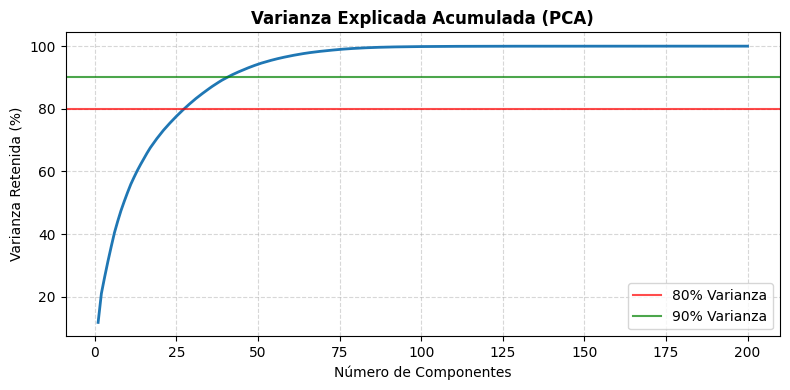

In [111]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, linewidth=2, color='#1f77b4')

ax.axhline(y=80, color='red', linestyle='-', alpha=0.7, label='80% Varianza')
ax.axhline(y=90, color='green', linestyle='-', alpha=0.7, label='90% Varianza')

ax.set_title('Varianza Explicada Acumulada (PCA)', fontweight='bold')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Varianza Retenida (%)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(IMAGENES_PATH + 'PCA_Varianza.png', dpi=150, bbox_inches='tight')
plt.show()

In [112]:
reducer = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=31,
)


In [113]:
embeddings_umap = reducer.fit_transform(embeddings)

# clasico estandar
scaler = StandardScaler()
embeddings_umap_scaled = scaler.fit_transform(embeddings_umap)

embeddings_umap_scaled.shape

c:\Proyectos\GameLens\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(19778, 10)

In [114]:
for mcs in [2000,1000,500,400,300]:
    labels_test = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',).fit_predict(embeddings_umap_scaled)
    
    conteo = pd.Series(labels_test).value_counts().sort_index()
    n_c = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_r = (labels_test == -1).sum()
    print(f'\nmcs={mcs}: {n_c} clusters  ruido={n_r:,} ({n_r/len(labels_test)*100:.1f}%)')
    print(conteo.to_string())
    print('---')


mcs=2000: 0 clusters  ruido=19,778 (100.0%)
-1    19778
---

mcs=1000: 2 clusters  ruido=2,275 (11.5%)
-1     2275
 0     1096
 1    16407
---

mcs=500: 3 clusters  ruido=1,387 (7.0%)
-1     1387
 0      888
 1     1096
 2    16407
---

mcs=400: 4 clusters  ruido=907 (4.6%)
-1      907
 0      888
 1      480
 2     1096
 3    16407
---

mcs=300: 4 clusters  ruido=907 (4.6%)
-1      907
 0      888
 1      480
 2     1096
 3    16407
---


In [115]:
labels = hdbscan.HDBSCAN(
    min_cluster_size=450,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
).fit_predict(embeddings_umap_scaled)

In [116]:
df_modelo['cluster']=labels

In [118]:
### redujo mucho el proceso de limpieza

In [117]:
for cid in sorted(df_modelo['cluster'].unique()):
    n = (df_modelo['cluster'] == cid).sum()
    muestra = df_modelo[df_modelo['cluster'] == cid]['resena_limpia'].sample(20, random_state=31)
    print(f'\n=== Cluster {cid} ({n:,} reseñas) ===')
    for r in muestra:
        print(f'  - {r[:120]}')


=== Cluster -1 (907 reseñas) ===
  - un jugador modo historia online coperativo coperativo local (misma pc) mo gráficos estilo visual horribles malos normale
  - -decepción- gráficosdecepción- - no podrás diferenciarlos de la realidad hermoso buenos decentes malos no lo mires demas
  - -decepción- gráficosdecepción- - hermoso buenos normales malos horribles -decepción- gameplaydecepción- - muy bueno sufi
  - efotball pes 2020 review gráficos botón_cuadrado_con_borde_negro malos buenos botón_cuadrado_con_borde_negro hermososl b
  - decepción gráficos decepción- extremos bonito bueno decente malo sin opinión inexistentes decepción jugabilidad decepció
  - que tan dificil? es ajustable izi pizi facilillo normal cuadrado_rojo ta hardcore (empieza facil pero el rng termina mat
  - seid ihr das esen? nein, wir sind die j ger! fumareta hana no namae mo shirazu ni chi ni ochita tori wa kaze o machiwabi
  - cuadrado_negro_grande cuadrado_blanco_grande cuadrado_negro_grande cuadrado_blanco_gran

In [89]:
reducer = umap.UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=31,
)

embeddings_umap = reducer.fit_transform(embeddings_bert)

scaler = StandardScaler()
embeddings_umap_scaled = scaler.fit_transform(embeddings_umap)

print(f'Shape UMAP: {embeddings_umap_scaled.shape}')

c:\Proyectos\GameLens\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape UMAP: (598450, 5)


In [92]:
for mcs in [100000,50000,20000,10000,5000,2000,1000, 500, 400, 300]:
    labels_test = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',
    ).fit_predict(embeddings_umap_scaled)
    
    conteo = pd.Series(labels_test).value_counts().sort_index()
    n_c = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_r = (labels_test == -1).sum()
    print(f'\nmcs={mcs}: {n_c} clusters  ruido={n_r:,} ({n_r/len(labels_test)*100:.1f}%)')
    print(conteo.to_string())
    print('---')


mcs=100000: 0 clusters  ruido=598,450 (100.0%)
-1    598450
---

mcs=50000: 2 clusters  ruido=239,792 (40.1%)
-1    239792
 0    278680
 1     79978
---

mcs=20000: 3 clusters  ruido=246,982 (41.3%)
-1    246982
 0     79978
 1    232685
 2     38805
---

mcs=10000: 5 clusters  ruido=299,717 (50.1%)
-1    299717
 0     79978
 1     23528
 2     13659
 3     15792
 4    165776
---

mcs=5000: 3 clusters  ruido=94,129 (15.7%)
-1     94129
 0      9903
 1      7953
 2    486465
---

mcs=2000: 11 clusters  ruido=71,656 (12.0%)
-1      71656
 0       2058
 1       2615
 2       2175
 3       2689
 4       3742
 5       2767
 6       9903
 7       4239
 8       2188
 9       7953
 10    486465
---

mcs=1000: 71 clusters  ruido=321,021 (53.6%)
-1     321021
 0       1415
 1       1595
 2       2058
 3       2615
 4       1406
 5       2175
 6       2689
 7       2767
 8       9903
 9       2313
 10      1211
 11      1487
 12      1504
 13      4239
 14      1084
 15      1022
 16      1114
 

In [ ]:
labels = hdbscan.HDBSCAN(
    min_cluster_size=2000,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
).fit_predict(embeddings_umap_scaled)

df_limpio['cluster'] = labels




=== Cluster -1 (71,656 reseñas) ===
  - hola
  - me encanta este titulo
  - buenardo!
  - ido
  - muy buen juego
  - buenardo
  - si
  - muy divertido
  - the feliz cat paso por aqui (0_ )
  - excelente!
  - extraordinario
  - g
  - juegazo
  - expresion_positiva_fuerte hermano
  - simplemente hermoso
  - estúpidamente perfecto
  - como me gusta ser autista para disfrutar de estas joyitas
  - excelente juego
  - absolute cinema
  - si

=== Cluster 0 (2,058 reseñas) ===
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty

=== Cluster 1 (2,615 reseñas) ===
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 

=== Cluster 2 (2,175 reseñas) ===
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen j

In [94]:
for cid in sorted(df_limpio['cluster'].unique()):
    n = (df_limpio['cluster'] == cid).sum()
    muestra = df_limpio[df_limpio['cluster'] == cid]['resena_limpia'].sample(20, random_state=31)
    print(f'\n=== Cluster {cid} ({n:,} reseñas) ===')
    for r in muestra:
        print(f'  - {r[:120]}')


=== Cluster -1 (71,656 reseñas) ===
  - es cine
  - nice
  - buenardopolis polinardio
  - i love this!
  - e
  - muy buen juego
  - ta bueno compralo
  - ta joya!
  - zarpado
  - cine
  - meh
  - si
  - piola
  - tabue
  - contenido_irrelevante
  - yes
  - g
  - sonic, yakuza, persona, bob esponja, es como smash bros para los autistas
  - meh
  - soy batman

=== Cluster 0 (2,058 reseñas) ===
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - g
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty
  - goty

=== Cluster 1 (2,615 reseñas) ===
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 
  - 

=== Cluster 2 (2,175 reseñas) ===
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  - buen juego
  